In [1]:
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [2]:
model = ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
img_path = '/download.jpg'
img = keras.utils.load_img(img_path, target_size=(224, 224))
x = keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

In [5]:
preds = model.predict(x)
# decode the results into a list of tuples (class, description, probability)
# (one such list for each sample in the batch)
print('Predicted:', decode_predictions(preds, top=5)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted: [('n02417914', 'ibex', np.float32(0.46609542)), ('n02423022', 'gazelle', np.float32(0.15811737)), ('n02415577', 'bighorn', np.float32(0.08800179)), ('n04604644', 'worm_fence', np.float32(0.06312369)), ('n02437616', 'llama', np.float32(0.055062868))]


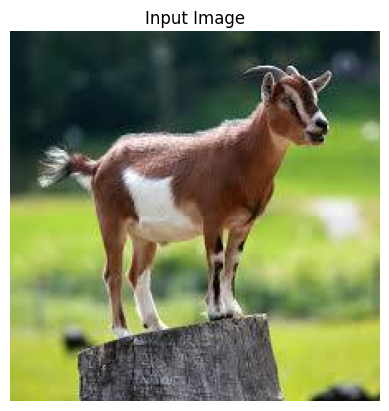

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Top Predictions:
1. ibex - 46.61%
2. gazelle - 15.81%
3. bighorn - 8.80%


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions


# Load pretrained ResNet50 model
model = ResNet50(weights="imagenet")


def predict_image(img_path, top_k=3):
    """
    Predict the class of an image using pretrained ResNet50.
    """

    if not os.path.exists(img_path):
        print("Image not found:", img_path)
        return

    # Load image
    img = keras.utils.load_img(img_path, target_size=(224, 224))

    # Display image
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    # Convert image to array
    x = keras.utils.img_to_array(img)

    # Add batch dimension: (224,224,3) -> (1,224,224,3)
    x = np.expand_dims(x, axis=0)

    # Preprocess for ResNet50
    x = preprocess_input(x)

    # Predict
    preds = model.predict(x)

    # Decode predictions
    results = decode_predictions(preds, top=top_k)[0]

    print("\nTop Predictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} - {probability*100:.2f}%")


# Example usage
img_path = "/download.jpg"
predict_image(img_path, top_k=3)

In [8]:
import gradio as gr
import numpy as np
import keras
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

# 1. Initialize the pre-trained ResNet50 model globally so it loads once
model = ResNet50(weights="imagenet")

def gradio_predict_image(input_img):
    """
    Core prediction function mapped directly to the Gradio web interface.
    Gradio natively passes images as NumPy arrays (RGB) by default.
    """
    if input_img is None:
        return "Please upload an image."

    # 2. Resize the raw NumPy array to fit ResNet50 expectations (224, 224, 3)
    # Using Keras processing utilities on the array matrix structure
    img_resized = keras.utils.array_to_img(input_img).resize((224, 224))
    x = keras.utils.img_to_array(img_resized)

    # 3. Add the required batch dimension (1, 224, 224, 3)
    x = np.expand_dims(x, axis=0)

    # 4. Zero-center and normalize pixel color channels
    x = preprocess_input(x)

    # 5. Run inference through the network graph layers
    preds = model.predict(x)

    # 6. Parse predictions into a dictionary of class labels and probabilities
    # Gradio's Label component parses dictionaries directly to show progress bars
    results = decode_predictions(preds, top=3)[0]

    # Format output: {"label_name": float_probability_between_0_and_1}
    predictions_dict = {class_name: float(probability) for _, class_name, probability in results}

    return predictions_dict

# 7. Define the high-level high-utility Gradio Interface layout
demo = gr.Interface(
    fn=gradio_predict_image,
    inputs=gr.Image(label="Upload Target Image"),          # Standard drag & drop image input canvas
    outputs=gr.Label(num_top_classes=3, label="Predictions"), # Confidences rendered as visual bar charts
    title="ResNet50 Image Classifier",
    description="Drop any image here to instantly identify the top 3 primary objects using pre-trained ImageNet weights."
)

# 8. Start your application server
# In Google Colab, this automatically prints a shareable public URL link
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cf4e5eb50c28e8c9e6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
